# CS231a PSET 4

You can use this colab notebook to write your code in, which could save you the trouble of having to set up Python or installing packages.

In [1]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# enter the foldername in your Drive where you have saved the unzipped
# the files containing the '.npy' files needed for problem 2
# e.g. '/content/drive/MyDrive/cs231a'
FOLDERNAME = 'ps4_code'

assert FOLDERNAME is not None, "[!] Enter the foldername."

%cd drive/MyDrive/$FOLDERNAME
print('Files in this folder:')
%ls .

Mounted at /content/drive
/content/drive/MyDrive/ps4_code
Files in this folder:
data/                          p2.py           PSET4.ipynb
LearnedObservationModel.ipynb  p3.py           __pycache__/
p1.py                          plot_helper.py  trained_model.pth


# Problem 1: Extended Kalman Filter with a Nonlinear Observation Model

First, we need to be able to access the data for this problem. Run the following:

Now, you can fill out the logic for this problem. Once done, copy it to p1.py for submission to Gradescope.

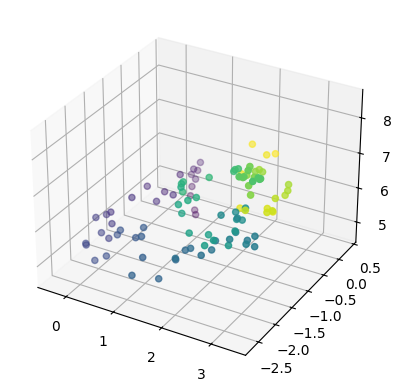

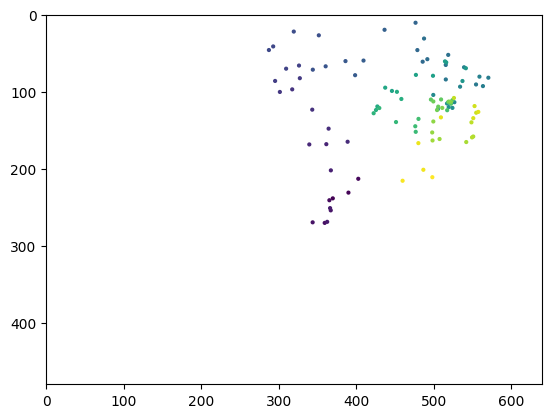

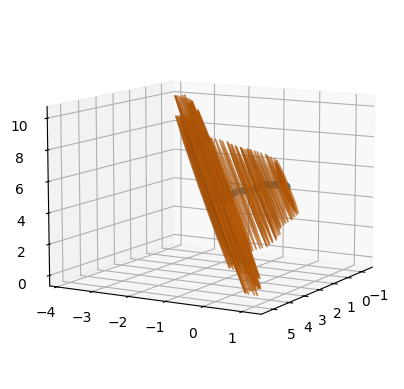

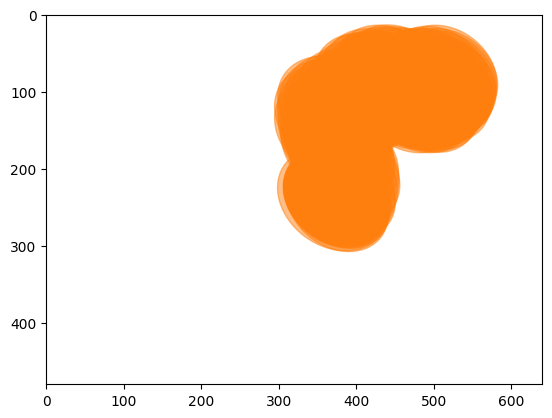

In [6]:
import numpy as np

class Q1_solution(object):

  @staticmethod
  def system_matrix():
    """ Implement the answer to Q2A here.
    Output:
      A: 6x6 numpy array for the system matrix.
    """
    A = np.eye(6)
    # TODO fill in values for A below
    # Hint: only 9 entries should be non-zero, with values 1, 0.1, and 0.8
    A[0,0], A[1,1], A[2,2] = 1.0, 1.0, 1.0
    A[0,3], A[1,4], A[2,5] = 0.1, 0.1, 0.1
    A[3, 3], A[4,4], A[5,5] = 0.8, 0.8, 0.8
    return A

  @staticmethod
  def process_noise_covariance():
    """ Implement the covariance matrix Q for process noise.
    Output:
      Q: 6x6 numpy array for the covariance matrix.
    """
    Q = np.eye(6)
    # TODO fill in values for Q below
    # Hint: only 3 entries should be non-zero, and all should equal 0.05]
    Q *= 0.05
    return Q

  @staticmethod
  def observation_noise_covariance():
    """ Implement the covariance matrix R for observation noise.
    Output:
      R: 2x2 numpy array for the covariance matrix.
    """
    R = np.eye(2)
    # TODO fill in values for R below
    # Hint: only 2 entries should be non-zero, and all should equal 5.0
    R *= 5.0
    return R

  @staticmethod
  def observation(state):
    """ Implement the function h, from state to noise-less observation. (Q2B)
    Input:
      state: (6,) numpy array representing state.
    Output:
      obs: (2,) numpy array representing observation.
    """
    # Hint: you should use the camera intrinsics here
    obs = np.ones(shape=(2, ))
    P = np.array([state[0], state[1], state[2], 1], dtype=np.float64)
    camera_ins = np.array([[500,0,320,0],
                           [0,500,240,0],
                           [0,0,1,0]])
    obs = camera_ins @ P
    obs = obs[:2] / obs[-1]
    return obs

  def simulation(self, T=100):
    """ simulate with fixed start state for T timesteps.
    Input:
      T: an integer (=100).
    Output:
      states: (T,6) numpy array of states, including the given start state.
      observations: (T,2) numpy array of observations, Including the observation of start state.
    Note:
      We have set the random seed for you. Please only use np.random.multivariate_normal to sample noise.
      Keep in mind this function will be reused for Q3 by inheritance.
    """
    x_0 = np.array([0.5, 0.0, 5.0, 0.0, 0.0, 0.0])
    states = [x_0]
    A = self.system_matrix()
    Q = self.process_noise_covariance()
    R = self.observation_noise_covariance()
    z_0 = self.observation(x_0) + np.random.multivariate_normal(np.zeros((R.shape[0],)), R)
    observations = [z_0]
    for t in range(1,T):
        x_0 = A @ x_0 + np.random.multivariate_normal(np.zeros((Q.shape[0],)), Q)
        z = self.observation(x_0) + np.random.multivariate_normal(np.zeros((R.shape[0],)), R)
        states.append(x_0)
        observations.append(z)
    return np.array(states), np.array(observations)

  @staticmethod
  def observation_state_jacobian(x):
    """ Implement your answer for Q2D.
    Input:
      x: (6,) numpy array, the state we want to do jacobian at.
    Output:
      H: (2,6) numpy array, the jacobian of the observation model w.r.t state.
    """
    H = np.zeros((2,6))
    # Hint: four values in the Jacobian should be non-zero
    M = np.array([[500,0,320,0],
                  [0,500,240,0],
                  [0,0,1,0]])
    z = M @ np.array([x[0],x[1],x[2],1])
    dx = M.T @ np.array([1/z[-1], 0, -1/z[-1]**2])
    H[0] = np.array([dx[0], dx[1], dx[2], 0, 0, 0])
    dy = M.T @ np.array([0, 1/z[-1], -1/z[-1]**2])
    H[1] = np.array([dy[0], dy[1], dy[2], 0, 0, 0])
    return H

  def EKF(self, observations):
    """ Implement Extended Kalman filtering (Q2E)
    Input:
      observations: (N,2) numpy array, the sequence of observations. From T=1.
      mu_0: (6,) numpy array, the mean of state belief after T=0
      sigma_0: (6,6) numpy array, the covariance matrix for state belief after T=0.
    Output:
      state_mean: (N,6) numpy array, the filtered mean state at each time step. Not including the
                  starting state mu_0.
      state_sigma: (N,6,6) numpy array, the filtered state covariance at each time step. Not including
                  the starting state covarance matrix sigma_0.
      predicted_observation_mean: (N,2) numpy array, the mean of predicted observations. Start from T=1
      predicted_observation_sigma: (N,2,2) numpy array, the covariance matrix of predicted observations. Start from T=1
    Note:
      Keep in mind this function will be reused for Q2 by inheritance.
    """
    mu_0 = np.array([0.5, 0.0, 5.0, 0.0, 0.0, 0.0])
    sigma_0 = np.eye(6)*0.01
    sigma_0[3:,3:] = 0.0
    A = self.system_matrix()
    Q = self.process_noise_covariance()
    R = self.observation_noise_covariance()
    state_mean = [mu_0]
    state_sigma = [sigma_0]
    predicted_observation_mean = []
    predicted_observation_sigma = []
    for ob in observations:
        mu_bar_next = A @ state_mean[-1] # TODO fill this in
        sigma_bar_next = A @ state_sigma[-1] @ A.T + Q # TODO fill this in
        H = self.observation_state_jacobian(mu_bar_next) # TODO fill this in
        kalman_gain_numerator =  sigma_bar_next @ H.T# TODO fill this in
        kalman_gain_denominator = H @ sigma_bar_next @ H.T + R # TODO fill this in
        kalman_gain = kalman_gain_numerator @ np.linalg.inv(kalman_gain_denominator) # TODO fill this in
        expected_observation = self.observation(mu_bar_next) # TODO fill this in
        mu_next = mu_bar_next + kalman_gain @ (ob - expected_observation) # TODO fill this in
        sigma_next = sigma_bar_next - kalman_gain @ H @ sigma_bar_next # TODO fill this in
        state_mean.append(mu_next)
        state_sigma.append(sigma_next)
        predicted_observation_mean.append(expected_observation)
        predicted_observation_sigma.append(kalman_gain_denominator)
    return np.array(state_mean[1:]), np.array(state_sigma[1:]), np.array(predicted_observation_mean), np.array(predicted_observation_sigma)


if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from plot_helper import draw_2d, draw_3d

    np.random.seed(402)
    solution = Q1_solution()
    states, observations = solution.simulation()
    # plotting
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(states[:,0], states[:,1], states[:,2], c=np.arange(states.shape[0]))
    plt.show()

    fig = plt.figure()
    plt.scatter(observations[:,0], observations[:,1], c=np.arange(states.shape[0]), s=4)
    plt.xlim([0,640])
    plt.ylim([0,480])
    plt.gca().invert_yaxis()
    plt.show()

    observations = np.load('./data/Q1E_measurement.npy')
    filtered_state_mean, filtered_state_sigma, predicted_observation_mean, predicted_observation_sigma = \
        solution.EKF(observations)
    # plotting
    true_states = np.load('./data/Q1E_state.npy')
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(true_states[:,0], true_states[:,1], true_states[:,2], c='C0')
    for mean, cov in zip(filtered_state_mean, filtered_state_sigma):
        draw_3d(ax, cov[:3,:3], mean[:3])
    ax.view_init(elev=10., azim=30)
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(observations[:,0], observations[:,1], s=4)
    for mean, cov in zip(predicted_observation_mean, predicted_observation_sigma):
        draw_2d(ax, cov, mean)
    plt.xlim([0,640])
    plt.ylim([0,480])
    plt.gca().invert_yaxis()
    plt.show()

# Problem 2: From Monocular to Stereo Vision

First, make sure you have already run the code block for having access to numpy files from Problem 1. Then, complete this code and then copy it to p2.py for submission to Gradescope.

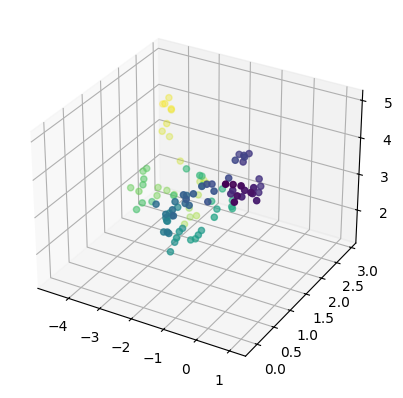

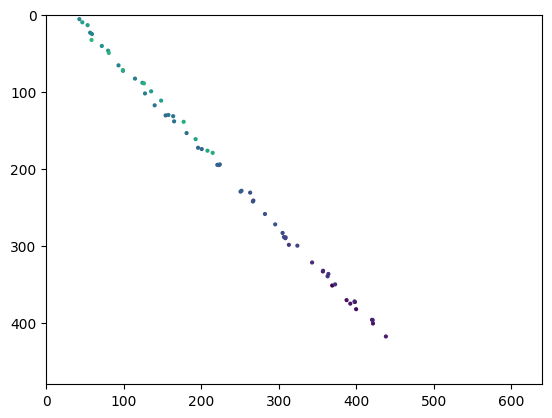

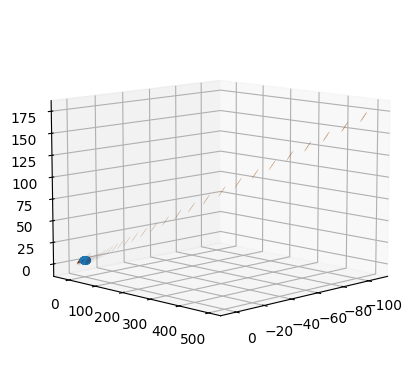

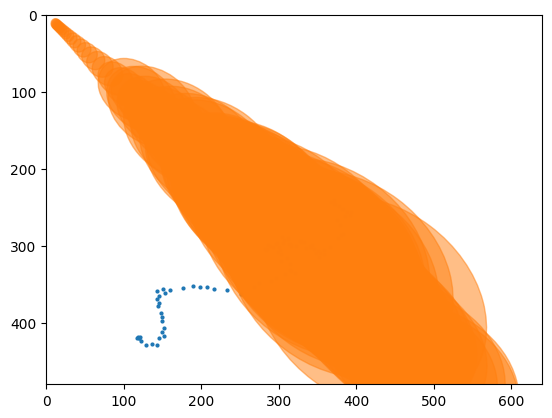

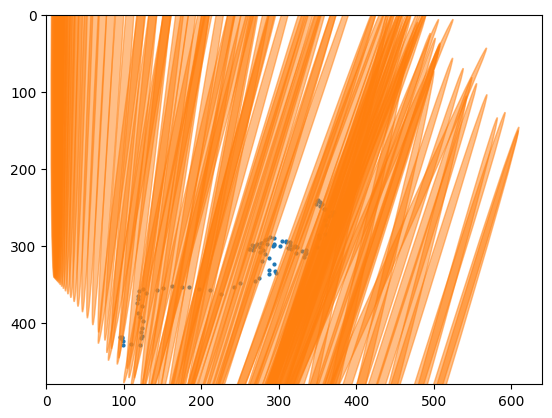

In [11]:
import numpy as np
# from .p1 import Q1_solution


class Q2_solution(Q1_solution):
    @staticmethod
    def observation(x):
        """Implement Q3A. Observation function without noise.
        Input:
          x: (6,) numpy array representing the state.
        Output:
          obs: (3,) numpy array representing the observation (u,v,d).
        Note:
          we define disparity to be possitive.
        """
        # Hint: this should be similar to your implemention in Q2, but with two cameras
        P1 = np.array([x[0], x[1], x[2], 1], dtype=np.float64)
        camera_ins = np.array([[500,0,320,0],
                               [0,500,240,0],
                               [0,0,1,0]])
        p1 = camera_ins @ P1
        p1 = p1[:2]/p1[-1]
        P2 = np.array([x[0]-0.2, x[1], x[2], 1], dtype=np.float64)
        p2 = camera_ins @ P2
        p2 = p2[:2]/p2[-1]

        obs = np.array([p1[0], p2[0], np.abs(p1[0]-p2[0])])

        return obs

    @staticmethod
    def observation_state_jacobian(x):
        """Implement Q3B. The jacobian of observation function w.r.t state.
        Input:
          x: (6,) numpy array, the state to take jacobian with.
        Output:
          H: (3,6) numpy array, the jacobian H.
        """
        H = np.zeros((3, 6))
        M = np.array([[500,0,320,0],
                      [0,500,240,0],
                      [0,0,1,0]])
        z = M @ np.array([x[0],x[1],x[2],1])
        dx = M.T @ np.array([1/z[-1], 0, -1/z[-1]**2])
        H[0] = np.array([dx[0], dx[1], dx[2], 0, 0, 0])
        dy = M.T @ np.array([0, 1/z[-1], -1/z[-1]**2])
        H[1] = np.array([dy[0], dy[1], dy[2], 0, 0, 0])
        d_disp = M.T @ np.array([1, 0, 0])
        H[2] = np.array([d_disp[0], d_disp[1], d_disp[2], 0, 0, 0])
        return H

    @staticmethod
    def observation_noise_covariance():
        """Implement Q3C here.
        Output:
          R: (3,3) numpy array, the covariance matrix for observation noise.
        """
        R = np.array([[5.0,0,0],
                      [0,5.0,0],
                      [0,0,10.0]])
        return R


if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from plot_helper import draw_2d, draw_3d

    np.random.seed(315)
    solution = Q2_solution()
    states, observations = solution.simulation()
    # plotting
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(states[:, 0], states[:, 1], states[:, 2], c=np.arange(states.shape[0]))
    plt.show()

    fig = plt.figure()
    plt.scatter(
        observations[:, 0], observations[:, 1], c=np.arange(states.shape[0]), s=4
    )
    plt.xlim([0, 640])
    plt.ylim([0, 480])
    plt.gca().invert_yaxis()
    plt.show()

    observations = np.load("./data/Q2D_measurement.npy")
    (
        filtered_state_mean,
        filtered_state_sigma,
        predicted_observation_mean,
        predicted_observation_sigma,
    ) = solution.EKF(observations)
    # plotting
    true_states = np.load("./data/Q2D_state.npy")
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(true_states[:, 0], true_states[:, 1], true_states[:, 2], c="C0")
    for mean, cov in zip(filtered_state_mean, filtered_state_sigma):
        draw_3d(ax, cov[:3, :3], mean[:3])
    ax.view_init(elev=10.0, azim=45)
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(observations[:, 0], observations[:, 1], s=4)
    for mean, cov in zip(predicted_observation_mean, predicted_observation_sigma):
        draw_2d(ax, cov[:2, :2], mean[:2])
    plt.xlim([0, 640])
    plt.ylim([0, 480])
    plt.gca().invert_yaxis()
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(observations[:, 0] - observations[:, 2], observations[:, 1], s=4)
    for mean, cov in zip(predicted_observation_mean, predicted_observation_sigma):
        # TODO find out the mean and convariance for (u^R, v^R).
        right_mean = mean
        right_cov = cov
        draw_2d(ax, right_cov, right_mean)
    plt.xlim([0, 640])
    plt.ylim([0, 480])
    plt.gca().invert_yaxis()
    plt.show()


# Problem 3: Linear Kalman Filter with a Learned Inverse Observation Model
First, make sure you have already run the code block for having access to numpy files from Problem 2 if using colab.
Then, complete this code after running the cells in LearnedObervationModel.ipynb and then copy it to p3.py for submission to Gradescope.

In [ ]:
import numpy as np


# TODO fill out the following class, reusing your implementation from the
# prior problems
class Q3_solution(object):
    @staticmethod
    def system_matrix():
        """
        Output:
          A: 6x6 numpy array for the system matrix.
        """
        # Hint: this is the same as in part A
        raise NotImplementedError()
        return A

    @staticmethod
    def process_noise_covariance():
        """
        Output:
          Q: 6x6 numpy array for the covariance matrix.
        """
        # Hint: this is the same as in part A
        raise NotImplementedError()
        return Q

    @staticmethod
    def observation_noise_covariance():
        """
        Output:
          R: 2x2 numpy array for the covariance matrix.
        """
        sigma = np.diag([0.005, 0.005, 0.01])
        return sigma

    def KF(self, observations, mu_0, sigma_0, remove_outliers):
        """Implement Kalman filtering
        Input:
          observations: (N,3) numpy array, the sequence of observations. From T=1.
          mu_0: (6,) numpy array, the mean of state belief after T=0
          sigma_0: (6,6) numpy array, the covariance matrix for state belief after T=0.
          remove_outliers: bool, whether to remove outliers
        Output:
          state_mean: (N+1,6) numpy array, the filtered mean state at each time step, starting at T=0
          state_sigma: (N+1,6,6) numpy array, the filtered state covariance at each time step, starting at T=0
          predicted_observation_mean: (N,2) numpy array, the mean of predicted observations. Start from T=1
          predicted_observation_sigma: (N,2,2) numpy array, the covariance matrix of predicted observations. Start from T=1
        """
        A = self.system_matrix()
        Q = self.process_noise_covariance()
        R = self.observation_noise_covariance()
        state_mean = [mu_0]
        state_sigma = [sigma_0]
        predicted_observation_mean = []
        predicted_observation_sigma = []
        for ob in observations:
            mu_bar_next = None  # TODO fill this in
            sigma_bar_next = None  # TODO fill this in
            H = None  # TODO fill this in
            kalman_gain_numerator = None  # TODO fill this in
            kalman_gain_denominator = None  # TODO fill this in
            kalman_gain = None  # TODO fill this in
            expected_observation = None  # TODO fill this in
            # for D outlier
            mu_next = None  # TODO fill this in
            sigma_next = None  # TODO fill this in
            deviation = None  # TODO fill this in
            if not filter_outliers or deviation <= 25:  # part D
                mu_next = None  # TODO fill this in
                sigma_next = None  # TODO fill this in
            else:
                mu_next = None  # TODO fill this in
                sigma_next = None  # TODO fill this in
            state_mean.append(mu_next)
            state_sigma.append(sigma_next)
            predicted_observation_mean.append(expected_observation)
            predicted_observation_sigma.append(kalman_gain_denominator)
        return (
            state_mean,
            state_sigma,
            predicted_observation_mean,
            predicted_observation_sigma,
        )


if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from plot_helper import draw_2d, draw_3d

    part_b_data = False
    filter_outliers = False

    solution = Q3_solution()

    if part_b_data:
        state_positions = np.load("data/Q3B_data/Q3B_positions_gt.npy")
        observations = np.load("./data/Q3B_predictions.npy")
    else:
        state_positions = np.load("data/Q3D_data/Q3D_positions_gt.npy")
        observations = np.load("./data/Q3D_predictions.npy")

    state_0 = np.concatenate([state_positions[0], np.zeros(3)])
    sigma_0 = np.eye(6) * 0.01
    sigma_0[3:, 3:] = 0.0
    (
        state_mean,
        state_sigma,
        predicted_observation_mean,
        predicted_observation_sigma,
    ) = solution.KF(observations[1:], state_0, sigma_0, filter_outliers)
    state_mean = np.array(state_mean)
    dev = np.linalg.norm(state_positions - state_mean[:, :3], axis=1)
    err = np.linalg.norm(state_positions - observations[:, :3], axis=1)

    # 3D plotting
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(state_mean[:, 0], state_mean[:, 1], state_mean[:, 2], c="C1")
    ax.scatter(
        state_positions[:, 0], state_positions[:, 1], state_positions[:, 2], c="C0"
    )
    plt.show()

    if not part_b_data:
        # 2d plotting
        fig = plt.figure()
        plt.scatter(state_positions[:, 0], state_positions[:, 2], c="C0")
        state_mean = np.array(state_mean)
        plt.scatter(state_mean[:, 0], state_mean[:, 2], c="C1")
        plt.show()

        fig = plt.figure()
        plt.scatter(state_positions[:, 1], state_positions[:, 2], c="C0")
        state_mean = np.array(state_mean)
        plt.scatter(state_mean[:, 1], state_mean[:, 2], c="C1")
        plt.show()

        if filter_outliers:

            def projection(points_3d):
                intrinsic = np.array([[500, 0, 320], [0, 500, 240], [0, 0, 1]])
                points_proj = np.dot(points_3d, intrinsic.transpose())
                points_proj = points_proj[:, :2] / points_proj[:, 2:3]
                return points_proj

            gt_state_proj = projection(state_positions)
            detection_proj = projection(observations)
            filtered_state_proj = projection(np.array(state_mean)[:, :3])

            fig = plt.figure()
            ax = fig.add_subplot(111)
            ax.scatter(gt_state_proj[:, 0], gt_state_proj[:, 1], s=4)
            ax.scatter(detection_proj[:, 0], detection_proj[:, 1], s=4)
            ax.scatter(filtered_state_proj[:, 0], filtered_state_proj[:, 1], s=4)
            plt.xlim([0, 640])
            plt.ylim([0, 480])
            plt.gca().invert_yaxis()
            plt.show()

That's it, you are done! Remember to submit your code by copying the code from Colab to p[X].py, and submitting it to Gradescope by zipping the .py files and uploading the zip file to the coding assignment.

